# Semantic Lifting

Demonstrates lifting MaskCLIP patch features into a reconstructed pointcloud and querying the 3D scene by text.

**Pipeline:**
1. Load a cached VGGT-X reconstruction (run `02_pointcloud/feedforward_methods` first)
2. Extract MaskCLIP patch features from the source frames
3. Lift features onto each 3D point
4. Compress features with a lightweight autoencoder
5. Query the pointcloud with text — per-point scores in [0, 1]
6. Visualise in an interactive PyVista viewer

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import zarr
from zarr.codecs import BloscCodec
from PIL import Image
from tqdm.auto import tqdm
import pyvista as pv
%matplotlib inline

from collab_splats.pointcloud.feedforward.base import FeedforwardResult
from collab_splats.semantics.features import MaskCLIPExtractor
from collab_splats.semantics.compression import FeatureAutoencoder
from collab_splats.pointcloud.utils import lift_features
from collab_splats.utils.visualization import pointcloud_to_polydata

## §0 — Configuration

In [ ]:
%run ../tutorial_config.py

# ── Configuration ─────────────────────────────────────────────────────────────
METHOD     = "vggtx"   # "vggtx" | "mapanything"
QUERIES    = ["tree", "bird feeder", "ground"]
NEGATIVES  = ["background"]
LATENT_DIM = 13

RECON     = CACHE_DIR / METHOD / "reconstruction.zarr"
LIFTED    = CACHE_DIR / METHOD / "ba" / "lifted.zarr"
LIFTED.parent.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

assert RECON.exists(), (
    f"Reconstruction not found at {RECON}. "
    "Run 02_pointcloud/feedforward_methods first."
)
print(f"Device: {DEVICE}  |  RECON: {RECON}")

## §1 — Load Reconstruction from Cache

In [4]:
# Load reconstruction from zarr cache
out = FeedforwardResult.load_zarr(RECON)
print(f"Loaded reconstruction: {out.pts3d.shape[0]:,} pts  |  {len(out.image_paths)} frames")

Loaded reconstruction: 500,000 pts  |  80 frames


## §2 — Inspect Outputs

In [5]:
pts3d         = out.pts3d          # (P, 3) float32
pixel_indices = out.pixel_indices  # (P, 3) int32  [frame_id, row, col]
colors        = out.colors         # (P, 3) uint8

print(f"pts3d:         {pts3d.shape}")
print(f"pixel_indices: {pixel_indices.shape}")
print(f"colors:        {colors.shape}")
print(f"image_paths:   {len(out.image_paths)} frames")

pts3d:         (500000, 3)
pixel_indices: (500000, 3)
colors:        (500000, 3)
image_paths:   80 frames


## §3 — MaskCLIP Feature Lifting

`lift_features` assigns each 3D point the MaskCLIP patch embedding from its source pixel.
Returns `(P, 768) float32`, L2-normalised.

In [6]:
if LIFTED.exists():
    # Load lifted features from cache — skip expensive GPU inference
    _store = zarr.open(str(LIFTED), mode="r")
    features = _store["features"][:]
    print(f"Loaded lifted features from cache: {LIFTED}  shape={features.shape}")
else:
    # Load all frame images from cache (out.image_paths from reconstruction)
    _pil_imgs = [Image.open(p).convert("RGB") for p in tqdm(out.image_paths, desc="Loading frames")]
    _image_size = (_pil_imgs[0].height, _pil_imgs[0].width)  # (H, W)

    # Extract MaskCLIP patch features — one (D, H_p, W_p) tensor per frame
    _extractor = MaskCLIPExtractor(device=DEVICE)
    feature_maps = _extractor.forward(_pil_imgs)  # list of (D, H_p, W_p)

    # Lift feature maps onto 3D points via bilinear upsampling
    features = lift_features(feature_maps, out.pixel_indices, image_size=_image_size)
    features = features.numpy() if hasattr(features, "numpy") else features
    print(f"Lifted features: {features.shape}  dtype={features.dtype}")

    # Save lifted features to cache for future runs
    _lz4 = BloscCodec(cname="lz4")
    _store = zarr.open(str(LIFTED), mode="w")
    _store.create_array("features", data=features, chunks=features.shape, compressors=_lz4)
    print(f"Saved lifted features → {LIFTED}")

Loaded lifted features from cache: ../../.cache/birds_c0043/vggtx/ba/lifted.zarr  shape=(500000, 768)


## §4 — Compress Features

`FeatureAutoencoder` trains on the lifted features, encodes to `LATENT_DIM` codes, then decodes back to the original 768-dim space. Text queries in §5 run on the decoded features — no changes to the scoring API needed.

In [7]:
feat_orig = torch.from_numpy(np.asarray(features))               # (P, 768) reference, CPU

ae = FeatureAutoencoder(input_dim=feat_orig.shape[1], latent_dim=LATENT_DIM)
ae.fit(feat_orig.to(DEVICE))                                      # tqdm progress bar per epoch

codes  = ae.per_point_encode(feat_orig.to(DEVICE))               # (P, LATENT_DIM) compressed
feat_t = ae.per_point_decode(codes).detach().cpu()               # (P, 768) reconstructed, CPU

# Reconstruction quality and memory savings
cosine_sim = F.cosine_similarity(feat_t, feat_orig).mean().item()
mem_orig   = feat_orig.numpy().nbytes / 1e6
mem_comp   = codes.detach().cpu().numpy().nbytes / 1e6
print(f"Latent dim:      {LATENT_DIM}  ({feat_orig.shape[1]}→{LATENT_DIM}, {feat_orig.shape[1] // LATENT_DIM}:1 ratio)")
print(f"Mean cosine sim: {cosine_sim:.4f}")
print(f"Memory:          {mem_orig:.1f} MB → {mem_comp:.1f} MB")

fit autoencoder:   0%|          | 0/10 [00:00<?, ?epoch/s]

fit autoencoder:   0%|          | 0/10 [00:02<?, ?epoch/s, loss=1.000195]

fit autoencoder:  10%|█         | 1/10 [00:02<00:24,  2.69s/epoch, loss=1.000195]

fit autoencoder:  10%|█         | 1/10 [00:05<00:24,  2.69s/epoch, loss=1.000000]

fit autoencoder:  20%|██        | 2/10 [00:05<00:21,  2.64s/epoch, loss=1.000000]

...

fit autoencoder:  90%|█████████ | 9/10 [00:23<00:02,  2.61s/epoch, loss=1.000000]

fit autoencoder:  90%|█████████ | 9/10 [00:25<00:02,  2.61s/epoch, loss=1.000000]

fit autoencoder: 100%|██████████| 10/10 [00:25<00:00,  2.50s/epoch, loss=1.000000]

fit autoencoder: 100%|██████████| 10/10 [00:25<00:00,  2.53s/epoch, loss=1.000000]

Latent dim:      13  (768→13, 59:1 ratio)
Mean cosine sim: 0.0000
Memory:          1536.0 MB → 26.0 MB


## §5 — Text Queries → Per-Point Scores

`compute_similarity` and `score_queries` operate on the compressed→decoded `feat_t` — no reshape needed.

In [8]:
# Instantiate extractor for text-query scoring (CLIP text encoder)
extractor = MaskCLIPExtractor(device=DEVICE)

# Move reconstructed features to extractor device before scoring
feat_q = feat_t.to(DEVICE)

# (P, D) → (P,)  contrastive score across all positive queries
scores    = extractor.score_queries(
    feat_q, positive=QUERIES, negative=NEGATIVES, temperature=0.05
).detach().cpu().numpy()

# (P, D) → (N_queries, P) → transpose → (P, Q)  per-query cosine similarities
per_query = extractor.compute_similarity(feat_q, QUERIES).detach().T.cpu().numpy()

print(f"scores:    {scores.shape}  min={scores.min():.3f}  max={scores.max():.3f}")
print(f"per_query: {per_query.shape}")

scores:    (500000,)  min=0.501  max=0.501
per_query: (500000, 3)


## §6 — Interactive 3D Viewer

Attach scores and per-query arrays to the pointcloud. Use the scalar selector in the side panel to switch between semantic views.

2026-05-23 08:42:29.279 (  75.278s) [    736918203740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


/tmp/ipykernel_1054973/3779715978.py:12: UserWarning: Failed to use notebook backend "trame": Please install `nest_asyncio2` to automagically launch the trame server without await. Or, to avoid `nest_asyncio2` run:

from pyvista.trame.jupyter import launch_server
await launch_server().ready

Falling back to a static output.
Available backends: "static", "none"
Install trame for interactive backends: pip install "pyvista[jupyter]"
  pl.show()


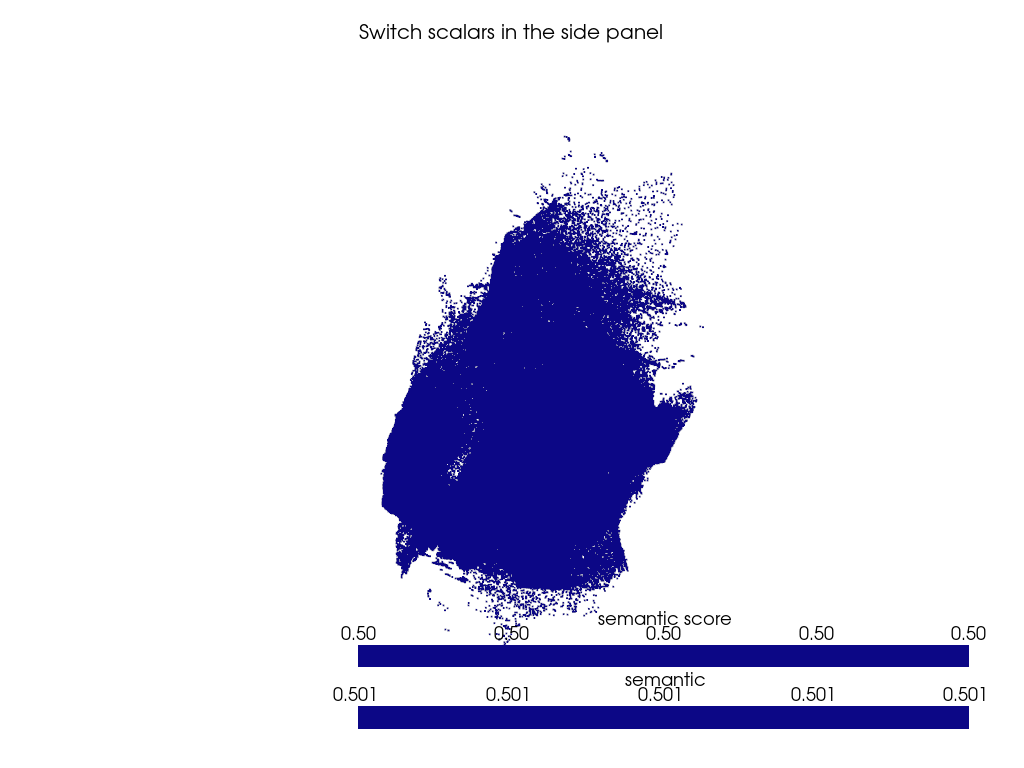

In [9]:
cloud = pointcloud_to_polydata(
    pts3d,
    RGB=colors,
    semantic=scores,
    **{q.replace(" ", "_"): per_query[:, i] for i, q in enumerate(QUERIES)},
)

pl = pv.Plotter(title="Semantic Lifting — C0043")
pl.add_mesh(cloud, scalars="semantic", cmap="plasma", point_size=2)
pl.add_scalar_bar("semantic score", fmt="%.2f")
pl.add_title('Switch scalars in the side panel', font_size=9)
pl.show()

## §7 — Multi-Query Tiled Gallery

One panel per query — linked cameras so you can orbit all views together.

/tmp/ipykernel_1054973/2834899512.py:8: UserWarning: Failed to use notebook backend "trame": Please install `nest_asyncio2` to automagically launch the trame server without await. Or, to avoid `nest_asyncio2` run:

from pyvista.trame.jupyter import launch_server
await launch_server().ready

Falling back to a static output.
Available backends: "static", "none"
Install trame for interactive backends: pip install "pyvista[jupyter]"
  pl.show()


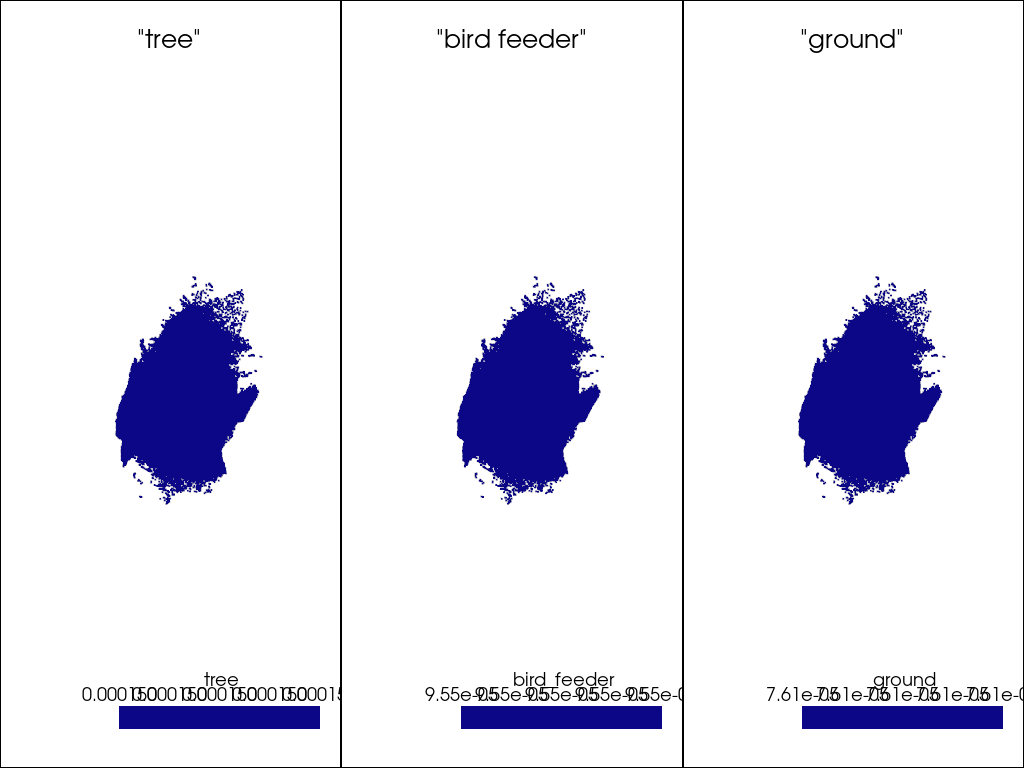

In [10]:
n  = len(QUERIES)
pl = pv.Plotter(shape=(1, n), title="Multi-Query Semantic Gallery — C0043")
for i, q in enumerate(QUERIES):
    pl.subplot(0, i)
    pl.add_mesh(cloud.copy(), scalars=q.replace(" ", "_"), cmap="plasma", point_size=2)
    pl.add_title(f'"{q}"', font_size=10)
pl.link_views()
pl.show()